In [1]:
import dask.dataframe as dd

train_file_path = r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\train_data.csv"
test_file_path = r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\test_data.csv"


dtypes = {
    'ActionGranular': 'object',
    'ActionGrouped': 'object',
    'AntispamDirection': 'object',
    'ResourceType': 'object',
    'Roles': 'object',
    'ThreatFamily': 'object'
}

df_train = dd.read_csv(train_file_path, dtype=dtypes, blocksize="100MB")
df_test = dd.read_csv(test_file_path, dtype=dtypes, blocksize="100MB")



In [2]:
df_train['IncidentGrade'].value_counts().compute()

IncidentGrade
BenignPositive    4110817
FalsePositive     2031967
TruePositive      3322713
Name: count, dtype: int64[pyarrow]

In [3]:
# Step 3: Set sampling fraction to 50%
frac = 0.5
# Step 1: Clean up column names (in case of extra spaces)
df_train.columns = df_train.columns.str.strip()

# Step 2: Use 'IncidentGrade' instead of 'TriageLabel'
df_tp = df_train[df_train['IncidentGrade'] == 'TruePositive'].sample(frac=0.5, random_state=42)
df_bp = df_train[df_train['IncidentGrade'] == 'BenignPositive'].sample(frac=0.5, random_state=42)
df_fp = df_train[df_train['IncidentGrade'] == 'FalsePositive'].sample(frac=0.5, random_state=42)

# Step 3: Combine & compute
df_stratified_sample = dd.concat([df_tp, df_bp, df_fp])
df_sampled = df_stratified_sample.compute()
aqaa
# Step 4: Save to CSV
output_path = r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_50.csv"
df_sampled.to_csv(output_path, index=False)

print("✅ Stratified sample created using 'IncidentGrade' and saved successfully.")
# Step 8: Check the class distribution to verify stratification
print("Class distribution in 50% sample:")
print(df_sampled['IncidentGrade'].value_counts(normalize=True))



✅ Stratified sample created using 'IncidentGrade' and saved successfully.
Class distribution in 50% sample:
IncidentGrade
BenignPositive    0.434295
TruePositive      0.351034
FalsePositive     0.214671
Name: proportion, dtype: double[pyarrow]


In [4]:
import pandas as pd

# Load the sampled data
df = pd.read_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_50.csv")

# Check class balance
print("Class counts:\n", df['IncidentGrade'].value_counts())
print("\nClass distribution (%):\n", df['IncidentGrade'].value_counts(normalize=True) * 100)


C:\Users\Jeba Jini\AppData\Local\Temp\ipykernel_7848\1816903961.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_50.csv")


Class counts:
 IncidentGrade
BenignPositive    2055408
TruePositive      1661358
FalsePositive     1015984
Name: count, dtype: int64

Class distribution (%):
 IncidentGrade
BenignPositive    43.429465
TruePositive      35.103439
FalsePositive     21.467096
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_50.csv")

print("Columns:", df.columns.tolist())


In [ ]:
import pandas as pd

# Load full test set
df_test = pd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\Test_data.csv",
    low_memory=False
)

# Clean column names and labels
df_test.columns = df_test.columns.str.strip()
df_test['IncidentGrade'] = df_test['IncidentGrade'].str.strip()

# Fraction of test data you want to sample
frac = 0.5

# Sample from each class
df_tp = df_test[df_test['IncidentGrade'] == 'TruePositive'].sample(frac=frac, random_state=42)
df_fp = df_test[df_test['IncidentGrade'] == 'FalsePositive'].sample(frac=frac, random_state=42)
df_bp = df_test[df_test['IncidentGrade'] == 'BenignPositive'].sample(frac=frac, random_state=42)

# Combine all sampled subsets
df_test_sampled = pd.concat([df_tp, df_fp, df_bp])

# Shuffle (optional but good practice)
df_test_sampled = df_test_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Save sampled test set
df_test_sampled.to_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_test_sample_50.csv", index=False)

print("✅ 50% stratified test set saved successfully.")
print(df_test_sampled['IncidentGrade'].value_counts(normalize=True) * 100)


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the 50% stratified sample
df_50 = pd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_50.csv",
    low_memory=False
)

# Clean column names and target column
df_50.columns = df_50.columns.str.strip()
df_50['IncidentGrade'] = df_50['IncidentGrade'].str.strip()

# Stratified sample: take 60% of the 50% sample → this gives 30% of the full data
df_30, _ = train_test_split(
    df_50,
    train_size=0.6,
    stratify=df_50['IncidentGrade'],
    random_state=42
)

# Save the 30% stratified sample
df_30.to_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_30.csv", index=False)

print("✅ 30% stratified sample extracted from 50% and saved successfully.")

C:\Users\Jeba Jini\anaconda3\Lib\site-packages\dask\dataframe\io\csv.py:77: DtypeWarning: Columns (10,11,31,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+-------------------+--------+----------+
| Column            | Found  | Expected |
+-------------------+--------+----------+
| ActionGranular    | object | float64  |
| ActionGrouped     | object | float64  |
| AntispamDirection | object | float64  |
| ResourceType      | object | float64  |
| Roles             | object | float64  |
| ThreatFamily      | object | float64  |
+-------------------+--------+----------+

The following columns also raised exceptions on conversion:

- ActionGranular
  ValueError("could not convert string to float: 'update stsrefreshtokenvalidfrom timestamp.'")
- ActionGrouped
  ValueError("could not convert string to float: 'ContainAccount'")
- AntispamDirection
  ValueError("could not convert string to float: 'Inbound'")
- ResourceType
  ValueError("could not convert string to float: 'Virtual Machine'")
- Roles
  ValueError("could not convert string to float: 'Destination'")
- ThreatFami

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the 50% stratified sample
df_50 = pd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_test_sample_50.csv",
    low_memory=False
)

# Clean column names and target column
df_50.columns = df_50.columns.str.strip()
df_50['IncidentGrade'] = df_50['IncidentGrade'].str.strip()

# Stratified sample: take 60% of the 50% sample → this gives 30% of the full data
df_30, _ = train_test_split(
    df_50,
    train_size=0.6,
    stratify=df_50['IncidentGrade'],
    random_state=42
)

# Save the 30% stratified sample
df_30.to_csv(r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_test_sample_30.csv", index=False)

print("✅ 30% stratified sample extracted from 50% and saved successfully.")


In [2]:
# === STEP 1: Load 30% stratified TRAIN data ===
# Already done using Dask 
df_train = dd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_30.csv",
    dtype={
        'ActionGrouped': 'object',
        'ActionGranular': 'object',
        'AntispamDirection': 'object',
        'ResourceType': 'object',
        'Roles': 'object',
        'ThreatFamily': 'object'
    },
    blocksize="100MB",
    assume_missing=True
)
df_train = df_train.compute()
df_train.info()
df_train.describe(include='all')
df_train['IncidentGrade'].value_counts(normalize=True) * 100


<class 'pandas.core.frame.DataFrame'>
Index: 2839650 entries, 0 to 405644
Data columns (total 45 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  float64
 1   OrgId               float64
 2   IncidentId          float64
 3   AlertId             float64
 4   Timestamp           string 
 5   DetectorId          float64
 6   AlertTitle          float64
 7   Category            string 
 8   MitreTechniques     string 
 9   IncidentGrade       string 
 10  ActionGrouped       string 
 11  ActionGranular      string 
 12  EntityType          string 
 13  EvidenceRole        string 
 14  DeviceId            float64
 15  Sha256              float64
 16  IpAddress           float64
 17  Url                 float64
 18  AccountSid          float64
 19  AccountUpn          float64
 20  AccountObjectId     float64
 21  AccountName         float64
 22  DeviceName          float64
 23  NetworkMessageId    float64
 24  EmailClusterId      float64
 2

IncidentGrade
BenignPositive    43.429472
TruePositive      35.103446
FalsePositive     21.467082
Name: proportion, dtype: double[pyarrow]

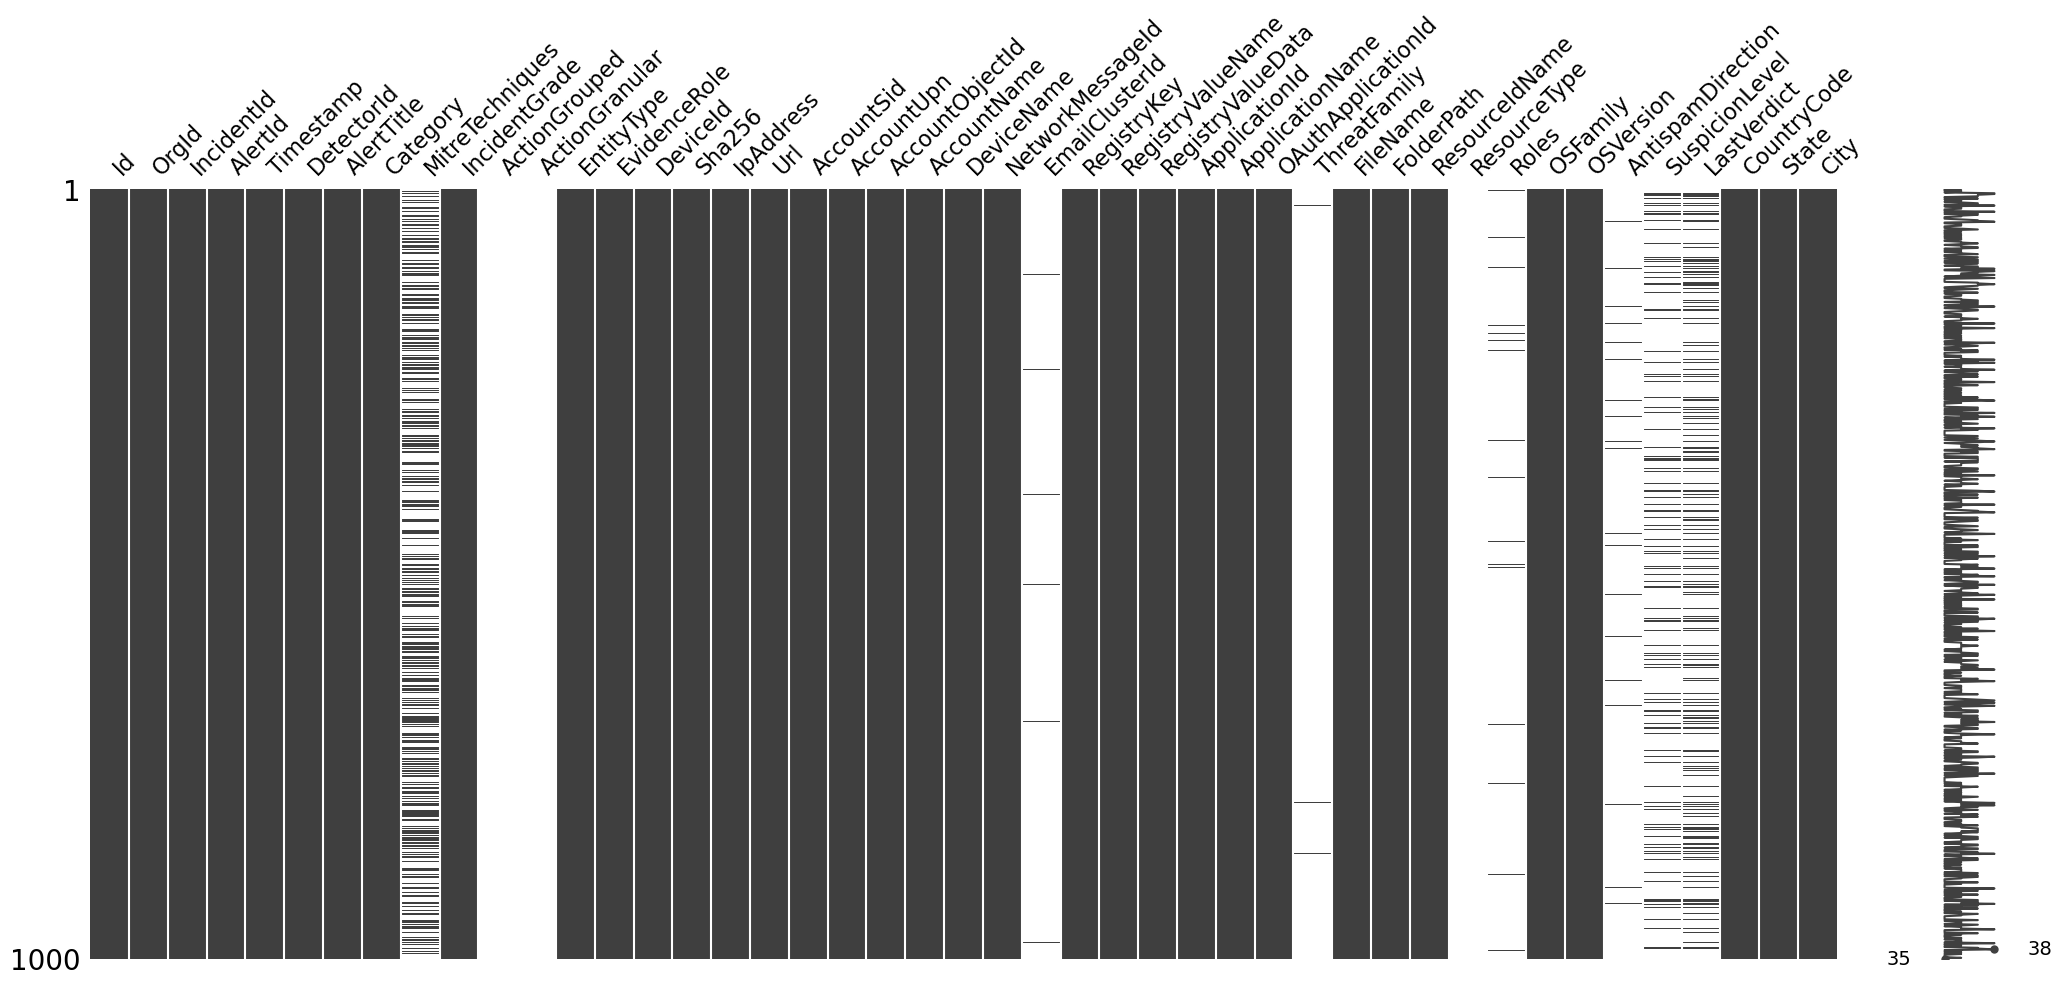

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # After installing

# Visual 1: Missing data heatmap
msno.matrix(df_train.sample(1000))
plt.show()

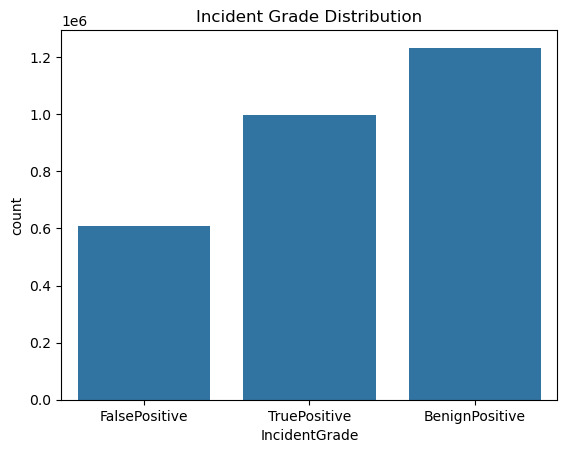

In [14]:
# Visual 2: IncidentGrade distribution
sns.countplot(data=df_train, x='IncidentGrade')
plt.title("Incident Grade Distribution")
plt.show()

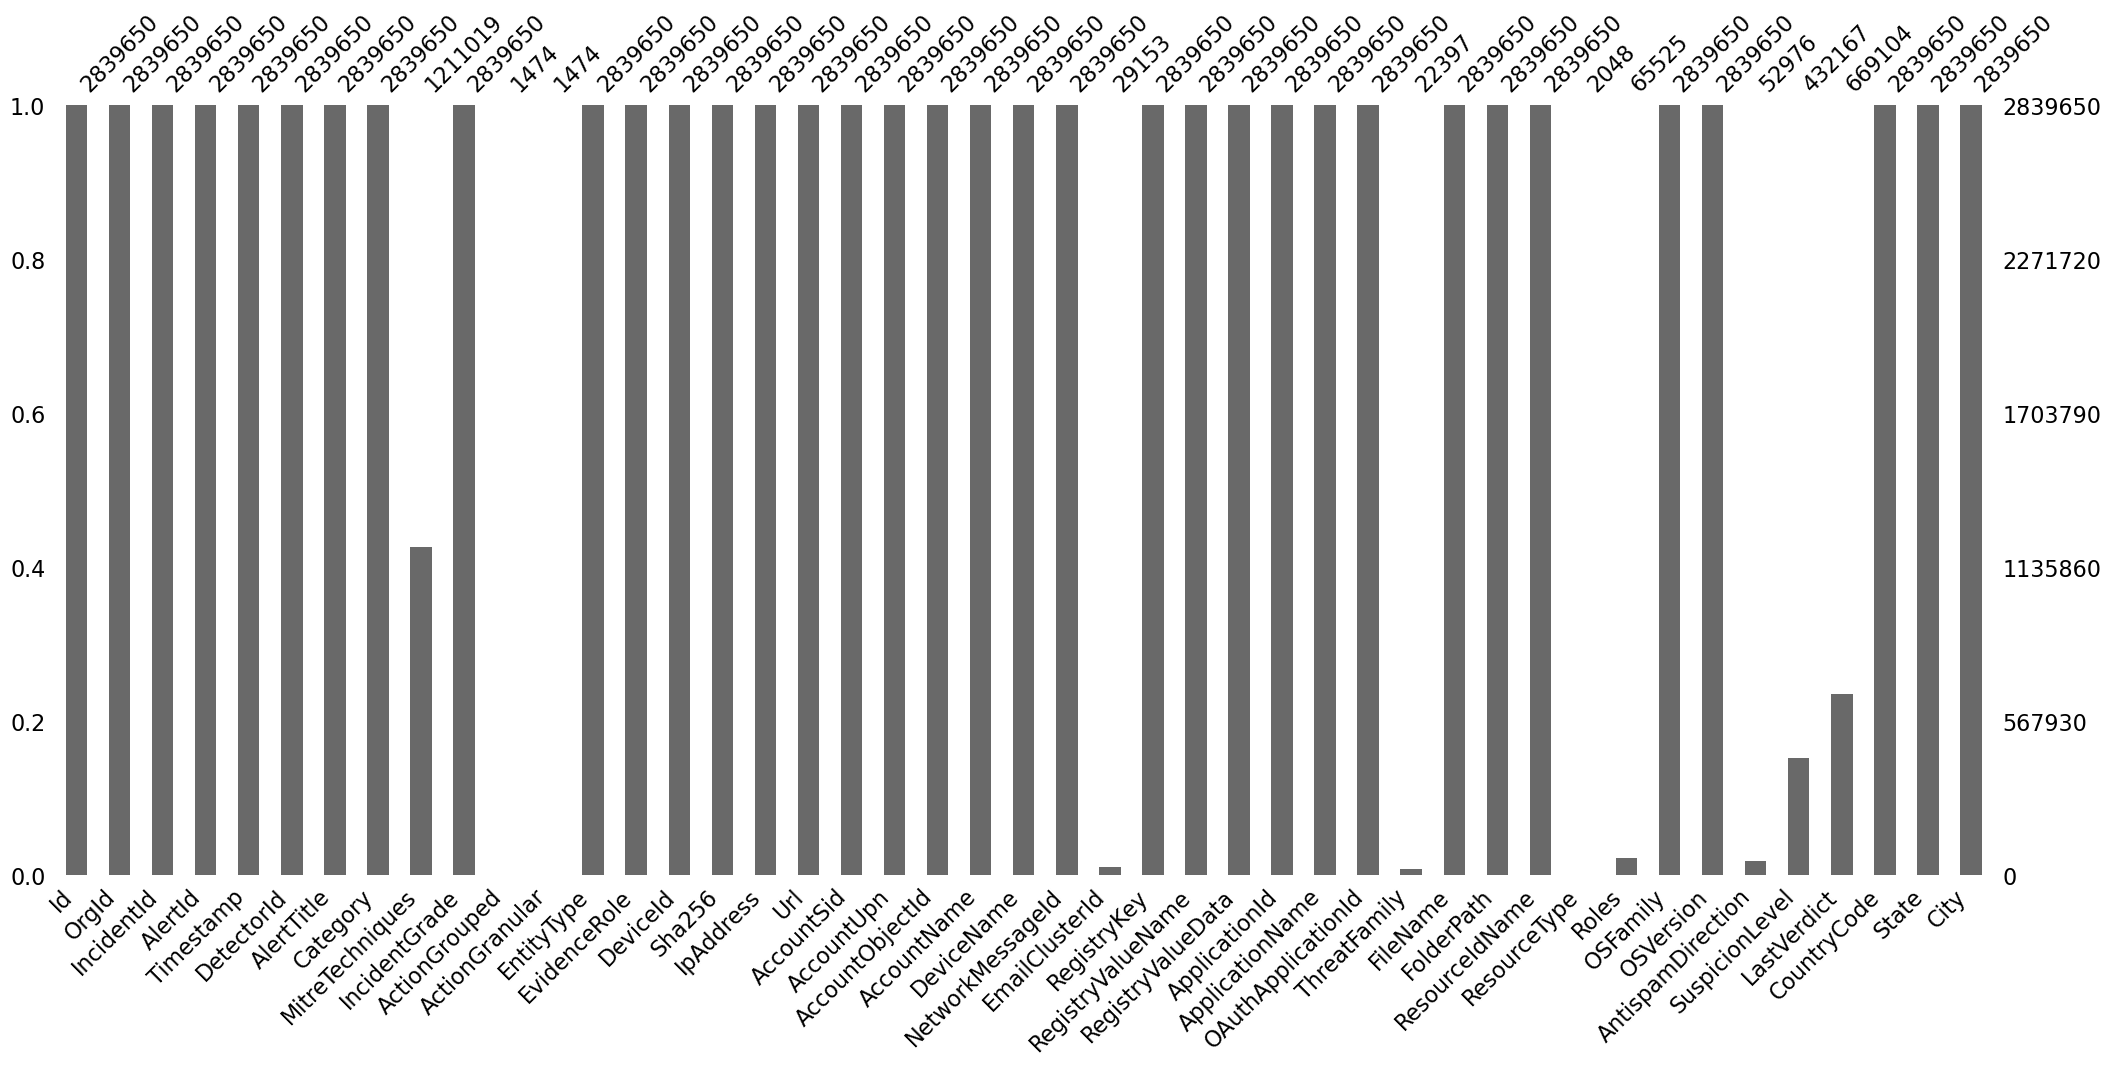

In [15]:
# Visual 3: Top features by missingness
msno.bar(df_train)
plt.show()


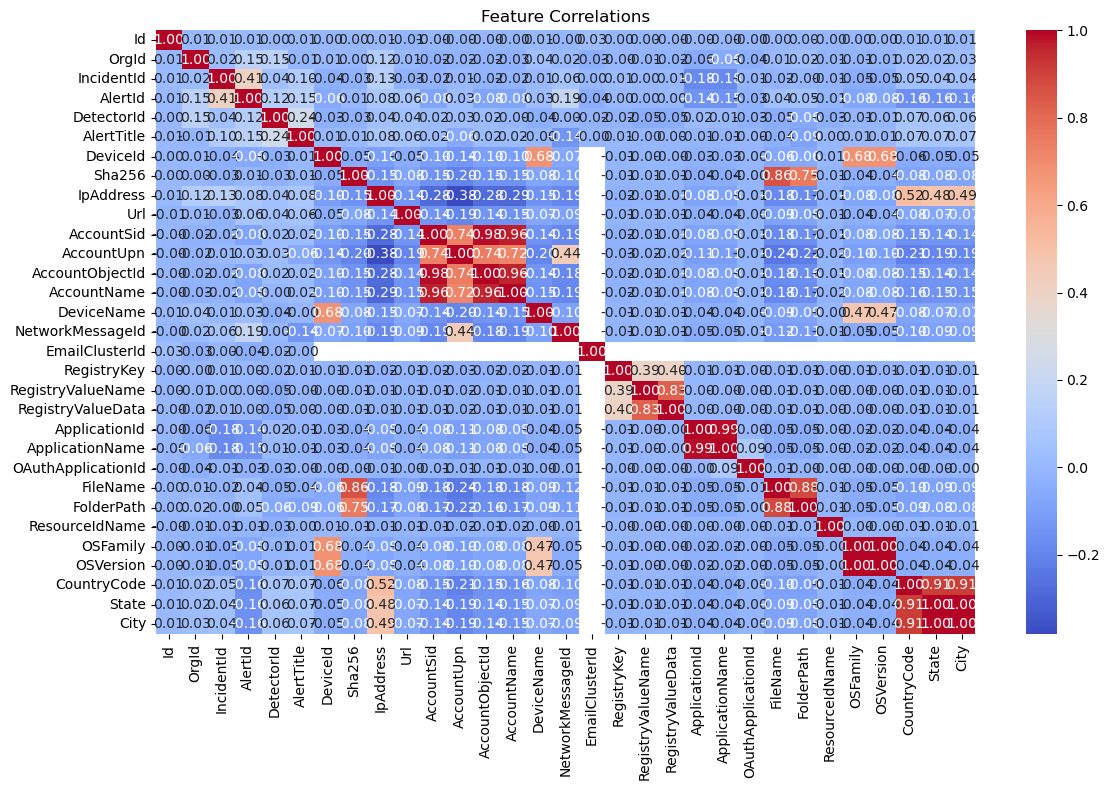

In [17]:
# Visual 4: Correlation heatmap for numerical columns
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_train[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd  # ✅ Add this if not already imported

# Drop duplicate columns
df_train = df_train.loc[:, ~df_train.columns.duplicated()]

# Drop duplicate index values
df_train = df_train.reset_index(drop=True)

# Ensure numeric conversion (important for boxplot y-axis)
df_train['SuspicionLevel'] = pd.to_numeric(df_train['SuspicionLevel'], errors='coerce')


In [10]:
# Define valid verdicts
valid_verdicts = ['Malicious', 'Suspicious', 'NoThreatsFound']

# Replace anything not in valid_verdicts with 'Other'
df_train['LastVerdict'] = df_train['LastVerdict'].where(df_train['LastVerdict'].isin(valid_verdicts), other='Other')


In [12]:
# Step 1: Define the valid LastVerdict values
valid_verdicts = ['Malicious', 'Suspicious', 'NoThreatsFound']

# Step 2: Filter the DataFrame to keep only rows with valid LastVerdict
df_filtered = df_train[df_train['LastVerdict'].isin(valid_verdicts)].copy()


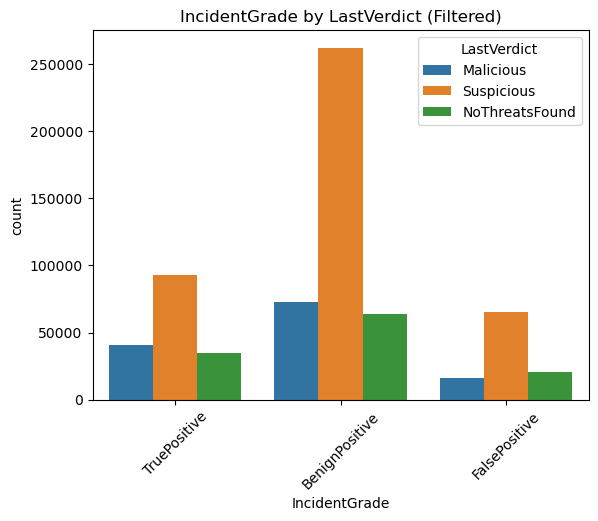

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Remove duplicate columns if any
df_train = df_train.loc[:, ~df_train.columns.duplicated()]

# Reset index to avoid mismatch
df_train = df_train.reset_index(drop=True)

# Plot
# Step 3: Plot the cleaned data
sns.countplot(data=df_filtered, x='IncidentGrade', hue='LastVerdict')
plt.title("IncidentGrade by LastVerdict (Filtered)")
plt.xticks(rotation=45)
plt.show()


In [7]:
print("Original rows:", len(df_train))
print("After cleaning:", len(df_plot))
print(df_plot.head())


Original rows: 2839650
After cleaning: 0
Empty DataFrame
Columns: [IncidentGrade, SuspicionLevel]
Index: []


In [8]:
print(df_train['SuspicionLevel'].value_counts(dropna=False).head(20))
print(df_train['SuspicionLevel'].unique()[:10])
print(df_train['SuspicionLevel'].dtype)


SuspicionLevel
<NA>    2839650
Name: count, dtype: Int64
<FloatingArray>
[<NA>]
Length: 1, dtype: Float64
Float64


In [1]:
import dask.dataframe as dd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# === STEP 1: Load 50% stratified TRAIN data using Dask ===
df_train = dd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_30.csv",
    dtype={
        'ActionGrouped': 'object',
        'ActionGranular': 'object',
        'AntispamDirection': 'object',
        'ResourceType': 'object',
        'Roles': 'object',
        'ThreatFamily': 'object'
    },
    blocksize="100MB",
    assume_missing=True
)

df_train = df_train.compute()

# === STEP 2: Preprocessing and Cleanup ===
df_train.columns = df_train.columns.str.strip()
df_train['IncidentGrade'] = df_train['IncidentGrade'].str.strip()

# Drop unnecessary columns
drop_cols = [
    'Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'Timestamp',
    'Sha256', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'DeviceId',
    'RegistryKey', 'RegistryValueName', 'RegistryValueData',
    'ApplicationId', 'OAuthApplicationId', 'FolderPath', 'ResourceIdName'
]
df_train = df_train.drop(columns=[col for col in drop_cols if col in df_train.columns])

# Separate features and target
target = 'IncidentGrade'
X = df_train.drop(columns=[target])
y = df_train[target]

# Identify categorical and numerical features
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# === STEP 3: Preprocessing Pipelines ===
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

preprocessor = ColumnTransformer([
    ('cat', categorical_pipeline, cat_cols),
    ('num', numerical_pipeline, num_cols)
])

# === STEP 4: Train/Validation Split (Stratified) ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === STEP 5: Model Pipeline ===
model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# === STEP 6: Train the Model ===
model_pipeline.fit(X_train, y_train)

# === STEP 7: Evaluation on Validation Set ===
y_val_pred = model_pipeline.predict(X_val)

print("\n📊 Validation Set Results:")
print(classification_report(y_val, y_val_pred))
print("✅ Validation Macro F1 Score:", f1_score(y_val, y_val_pred, average='macro'))

# === STEP 8: Load 50% Stratified TEST Data ===
df_test = pd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_test_sample_30.csv",
    low_memory=False,
    dtype={
        'ActionGrouped': 'object',
        'ActionGranular': 'object',
        'AntispamDirection': 'object',
        'ResourceType': 'object',
        'Roles': 'object',
        'ThreatFamily': 'object'
    }
)

df_test.columns = df_test.columns.str.strip()
df_test['IncidentGrade'] = df_test['IncidentGrade'].str.strip()
df_test = df_test.drop(columns=[col for col in drop_cols if col in df_test.columns])

# Separate features and target
X_test = df_test.drop(columns=[target])
y_test = df_test[target]

# === STEP 9: Evaluation on Final Test Set ===
y_test_pred = model_pipeline.predict(X_test)

print("\n🧪 Final Test Set Results:")
print(classification_report(y_test, y_test_pred))
print("✅ Final Macro F1 Score:", f1_score(y_test, y_test_pred, average='macro'))



📊 Validation Set Results:
                precision    recall  f1-score   support

BenignPositive       0.83      0.89      0.86    246649
 FalsePositive       0.80      0.70      0.75    121918
  TruePositive       0.85      0.83      0.84    199363

      accuracy                           0.83    567930
     macro avg       0.83      0.81      0.82    567930
  weighted avg       0.83      0.83      0.83    567930

✅ Validation Macro F1 Score: 0.8152915023831117

🧪 Final Test Set Results:
                precision    recall  f1-score   support

BenignPositive       0.79      0.86      0.82    525882
 FalsePositive       0.75      0.64      0.69    270809
  TruePositive       0.83      0.82      0.83    447706

      accuracy                           0.80   1244397
     macro avg       0.79      0.77      0.78   1244397
  weighted avg       0.80      0.80      0.80   1244397

✅ Final Macro F1 Score: 0.7801602152558146


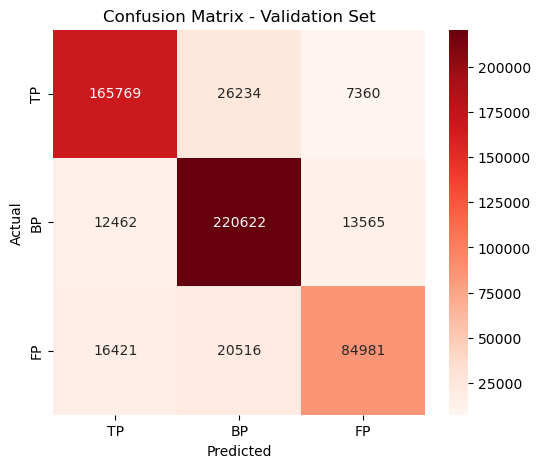

In [3]:
#Analyze the performance per class
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred, labels=['TruePositive', 'BenignPositive', 'FalsePositive'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['TP', 'BP', 'FP'], yticklabels=['TP', 'BP', 'FP'], cmap="Reds")
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [4]:
#Hyperparameter Tuning (Optional but Valuable)
#Use GridSearchCV to tune the Random Forest (number of trees, depth, etc.):

from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}

grid = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print("🔍 Best Params:", grid.best_params_)
print("✅ Best Validation F1 Macro Score:", grid.best_score_)

# Replace model_pipeline with grid.best_estimator_ for further steps if desired

C:\Users\Jeba Jini\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PicklingError: Could not pickle the task to send it to the workers.

In [10]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd

# === Load and Prepare Training Data ===
df_train = dd.read_csv(
    r"C:\Users\Jeba Jini\Documents\Pro 4 Microsoft security\stratified_train_sample_30.csv",
    blocksize="100MB",
    dtype={
        'ActionGrouped': 'object',
        'ActionGranular': 'object',
        'AntispamDirection': 'object',
        'ResourceType': 'object',
        'Roles': 'object',
        'ThreatFamily': 'object'
    },
    assume_missing=True
).compute()

df_train.columns = df_train.columns.str.strip()
df_train['IncidentGrade'] = df_train['IncidentGrade'].str.strip()

drop_cols = [
    'Id', 'OrgId', 'IncidentId', 'AlertId', 'DetectorId', 'Timestamp',
    'Sha256', 'Url', 'AccountSid', 'AccountUpn', 'AccountObjectId', 'DeviceId',
    'RegistryKey', 'RegistryValueName', 'RegistryValueData',
    'ApplicationId', 'OAuthApplicationId', 'FolderPath', 'ResourceIdName'
]
df_train = df_train.drop(columns=[col for col in drop_cols if col in df_train.columns])

target = 'IncidentGrade'
X = df_train.drop(columns=[target])
y = df_train[target]

# === Label Encoding for y ===
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# === Split ===
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42
)

# === Preprocessing Pipelines ===
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])
preprocessor = ColumnTransformer([
    ('cat', categorical_pipeline, cat_cols),
    ('num', numerical_pipeline, num_cols)
])

# === XGBoost Pipeline ===
model_pipeline_xgb = Pipeline([
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(eval_metric='mlogloss', random_state=42))
])

# === Train ===
model_pipeline_xgb.fit(X_train, y_train)

# === Predict and Evaluate ===
y_val_pred = model_pipeline_xgb.predict(X_val)
y_val_labels = label_encoder.inverse_transform(y_val)
y_val_pred_labels = label_encoder.inverse_transform(y_val_pred)

print("\n📊 XGBoost Validation Results:")
print(classification_report(y_val_labels, y_val_pred_labels))
print("✅ XGBoost Macro F1 Score:", f1_score(y_val_labels, y_val_pred_labels, average='macro'))

# === Feature Importance ===
clf_xgb = model_pipeline_xgb.named_steps['clf']
ohe = model_pipeline_xgb.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
feature_names = ohe.get_feature_names_out(cat_cols).tolist() + num_cols

importances = clf_xgb.feature_importances_
top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

# Plot
top_features.plot(kind='barh', title='Top 10 Feature Importances (XGBoost)', color='skyblue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



📊 XGBoost Validation Results:
                precision    recall  f1-score   support

BenignPositive       0.67      0.93      0.78    246649
 FalsePositive       0.78      0.40      0.53    121918
  TruePositive       0.84      0.67      0.75    199363

      accuracy                           0.73    567930
     macro avg       0.76      0.67      0.68    567930
  weighted avg       0.75      0.73      0.71    567930

✅ XGBoost Macro F1 Score: 0.6845059174166069


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [1]:
#Feature Importance For interpretability:

# After fitting
clf_rf = model_pipeline.named_steps['clf']
ohe = model_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
feature_names = ohe.get_feature_names_out(cat_cols).tolist() + num_cols
importances = clf_rf.feature_importances_

# Top 10 features
top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
top_features.plot(kind='barh', title='Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'model_pipeline' is not defined